PARTE 1 – IMPORTAÇÃO E EXPLORAÇÃO DOS
DADOS
1. Importe as bibliotecas necessárias para realizar a atividade.
2. Informe no código o caminho do arquivo Excel disponibilizado.
3. Faça a leitura da planilha utilizando o Pandas.
4. Mostre os primeiros registros do DataFrame.
5. Mostre a quantidade de linhas e colunas existentes no dataset.
6. Mostre os nomes das colunas disponíveis no dataset.

In [21]:
#
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

# ============================================================
# 1. CARREGAMENTO DO ARQUIVO
# ============================================================

caminho_arquivo = r"C:\Users\arthur.cr\Downloads\Dataset_Prova_Oficinas_50mil.xlsx"

df = pd.read_excel( caminho_arquivo, sheet_name="Servicos")

print("--- Primeiras linhas da base original ---")
print(df.head())
print("Quantidade de linhas:", len(df))



--- Primeiras linhas da base original ---
   id_ordem data_servico         cliente          cidade              oficina  \
0       NaN          NaN             NaN             NaN                  NaN   
1  OS000002   05/09/2026  Cliente 000002       CEILÂNDIA  Auto Center Central   
2  OS000003   07/03/2025  Cliente 000003   Águas Claras       Auto Center Sul   
3  OS000004   20/05/2025  Cliente 000004    ÁGUAS CLARAS  Auto Center Central   
4  OS000005   08/12/2025  Cliente 000005       Samambaia        Oficina Prime   

               categoria             servico tipo_veiculo valor_servico  \
0                    NaN                 NaN          NaN           NaN   
1        Ar-condicionado  Higienização do Ar       Picape        144,84   
2               Elétrica    Motor de Partida        Hatch        778,53   
3          Pneus e Rodas         Alinhamento          SUV      R$ 99,43   
4  Manutenção Preventiva       Troca de Óleo       Picape        391,80   

   quantidade    for

PARTE 2 – TRATAMENTO DOS DADOS – ETL
Realize os seguintes tratamentos:
1. Remova as linhas que estejam totalmente vazias.
2. Padronize a coluna cidade, realizando os tratamentos necessários para:
○ remover espaços extras;
○ corrigir diferenças entre letras maiúsculas e minúsculas.
3. Faça o tratamento da coluna valor_servico, removendo os caracteres utilizados
na representação monetária e preparando os valores para conversão.
4. Converta a coluna valor_servico para um tipo de dado numérico.
5. Converta a coluna data_servico para o formato de data.
6. Durante a conversão, faça com que datas inválidas sejam transformadas em
valores nulos.
7. Identifique e mostre a quantidade de registros duplicados existentes no dataset.
8. Remova os registros duplicados.
9. Identifique valores negativos existentes na coluna quantidade e realize o
tratamento adequado.
10. Ao final do processo de ETL, mostre novamente os primeiros registros do
DataFrame.


In [22]:
# 1. Remover linhas totalmente vazias
print("\n--- Removendo linhas totalmente vazias ---")
df = df.dropna(how="all")
print(f"Linhas após remoção de vazias: {len(df)}")

# 2. Padronizar a coluna cidade
print("\n--- Padronizando coluna cidade ---")
df["cidade"] = df["cidade"].astype("string").str.strip().str.lower()
print(df[["cidade"]].head())

# 3. Tratamento da coluna valor_servico
print("\n--- Tratando valor_servico ---")
df["valor_servico"] = (
    df["valor_servico"]
    .astype("string")
    .str.replace("R$", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
)

# 4. Converter para numérico
print("\n--- Convertendo valor_servico para numérico ---")
df["valor_servico"] = pd.to_numeric(df["valor_servico"], errors="coerce")
print(df[["valor_servico"]].head())

# 5 e 6. Converter data_servico e tratar datas inválidas como nulas
print("\n--- Convertendo data_servico ---")
df["data_servico"] = pd.to_datetime(df["data_servico"], errors="coerce", format="mixed")
print(df[["data_servico"]].head())

# 7. Identificar registros duplicados
print("\n--- Verificando duplicados ---")
quantidade_duplicados = df.duplicated().sum()
print(f"Quantidade de registros duplicados: {quantidade_duplicados}")

# 8. Remover duplicados
print("\n--- Removendo duplicados ---")
df = df.drop_duplicates()
print(f"Linhas após remoção de duplicados: {len(df)}")

# 9. Identificar valores negativos na coluna quantidade e tratar
print("\n--- Tratando valores negativos em quantidade ---")
quantidade_negativa = (df["quantidade"] < 0).sum()
print(f"Quantidade de valores negativos em 'quantidade': {quantidade_negativa}")

if quantidade_negativa > 0:
    df.loc[df["quantidade"] < 0, "quantidade"] = 0

print(df[["quantidade"]].head())

# 10. Mostrar os primeiros registros do DataFrame após o ETL
print("\n--- Primeiros registros após o ETL ---")
print(df.head())

print("\nETL finalizado.")


--- Removendo linhas totalmente vazias ---
Linhas após remoção de vazias: 49700

--- Padronizando coluna cidade ---
         cidade
1     ceilândia
2  águas claras
3  águas claras
4     samambaia
5     ceilândia

--- Tratando valor_servico ---

--- Convertendo valor_servico para numérico ---
   valor_servico
1         144.84
2         778.53
3          99.43
4          391.8
5         1118.5

--- Convertendo data_servico ---
  data_servico
1   2026-05-09
2   2025-07-03
3   2025-05-20
4   2025-08-12
5   2026-08-29

--- Verificando duplicados ---
Quantidade de registros duplicados: 645

--- Removendo duplicados ---
Linhas após remoção de duplicados: 49055

--- Tratando valores negativos em quantidade ---
Quantidade de valores negativos em 'quantidade': 581
   quantidade
1         2.0
2         1.0
3         2.0
4         1.0
5         3.0

--- Primeiros registros após o ETL ---
   id_ordem data_servico         cliente        cidade              oficina  \
1  OS000002   2026-05-09  Clien

PARTE 3 – GRÁFICO: SERVIÇOS POR CATEGORIA
Crie um gráfico de barras utilizando a coluna categoria que permita responder à
seguinte pergunta:
Qual categoria possui a maior quantidade de serviços realizados?
O gráfico deverá apresentar:
● título;
● identificação do eixo X;
● identificação do eixo Y;
● rotação dos textos quando necessária;
● organização adequada do layout.

Categoria com maior quantidade de serviços: Manutenção Preventiva


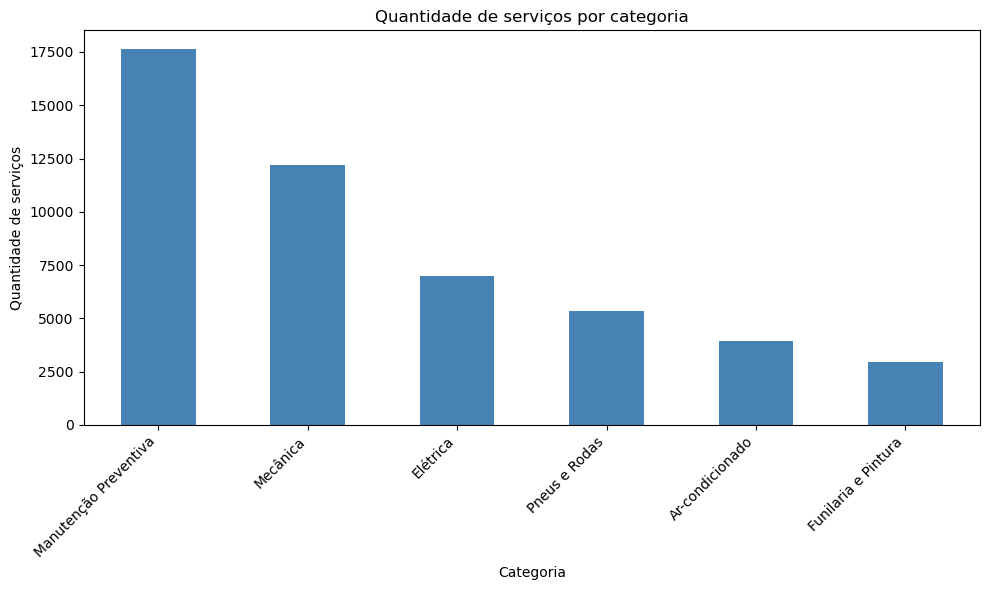

In [23]:
# 3. Gráfico: serviços por categoria
contagem_categoria = df["categoria"].value_counts().sort_values(ascending=False)

categoria_mais_frequente = contagem_categoria.idxmax()
print(f"Categoria com maior quantidade de serviços: {categoria_mais_frequente}")

plt.figure(figsize=(10, 6))
contagem_categoria.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Quantidade de serviços por categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de serviços")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

PARTE 4 – GRÁFICO: SERVIÇOS REALIZADOS
Crie um gráfico de barras utilizando a coluna servico que permita responder:
Quais são os serviços mais realizados pela rede de oficinas?
O gráfico deverá permitir uma comparação visual clara entre os diferentes serviços.
PARTE 5 – GRÁFICO: SERVIÇOS POR CIDADE
Utilizando a coluna cidade, crie um gráfico que permita responder:
Em quais cidades ocorre a maior quantidade de serviços?
O gráfico deverá possuir título e identificação adequada dos eixos.
PARTE 6 – GRÁFICO: FORMAS DE PAGAMENTO
Utilizando a coluna forma_pagamento, crie um gráfico que permita responder:
Qual é a forma de pagamento mais utilizada pelos clientes?
Escolha um dos tipos de gráficos trabalhados em aula que você considere adequado para
representar essas informações.


--- Serviços mais realizados ---
servico
Troca de Óleo                  7989
Revisão Geral                  5238
Troca de Pastilhas de Freio    4297
Troca de Correia               2991
Troca de Bateria               2936
Troca de Filtros               2655
Suspensão                      2491
Higienização do Ar             1973
Diagnóstico Elétrico           1910
Alinhamento                    1879
Name: count, dtype: int64


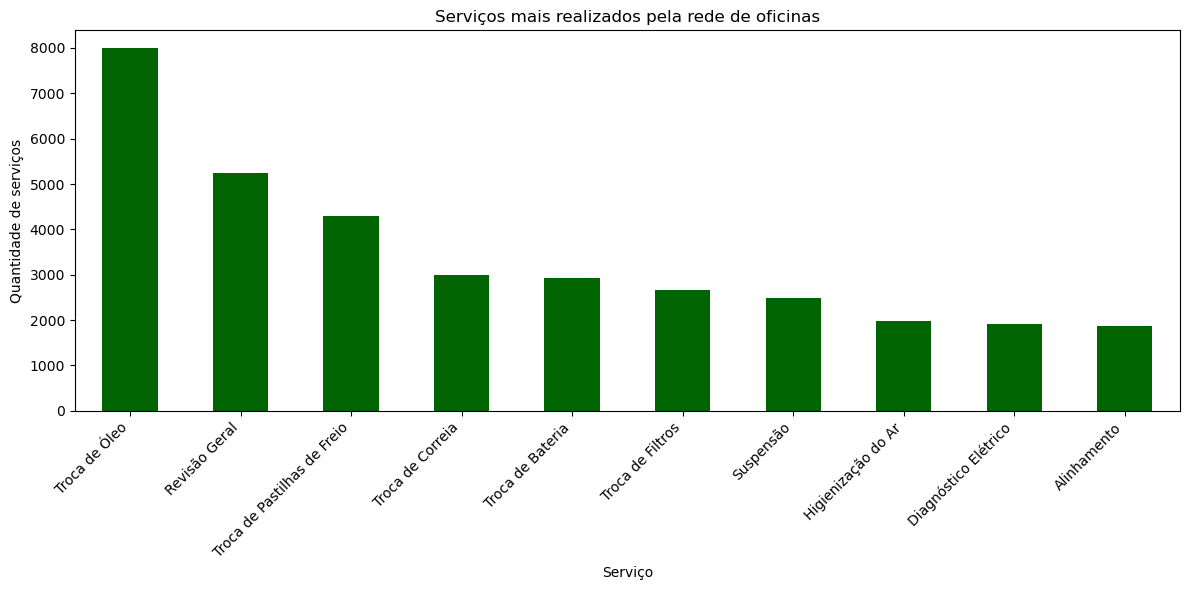

In [24]:
servicos_mais_realizados = df["servico"].value_counts().sort_values(ascending=False)

print("--- Serviços mais realizados ---")
print(servicos_mais_realizados.head(10))

plt.figure(figsize=(12, 6))
servicos_mais_realizados.head(10).plot(
kind="bar",
color="darkgreen"
)

plt.title("Serviços mais realizados pela rede de oficinas")
plt.xlabel("Serviço")
plt.ylabel("Quantidade de serviços")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

--- Serviços por cidade ---
cidade
brasília        16615
taguatinga       9355
ceilândia        7355
águas claras     4871
samambaia        3935
gama             2944
guará            2504
sobradinho       1476
Name: count, dtype: Int64


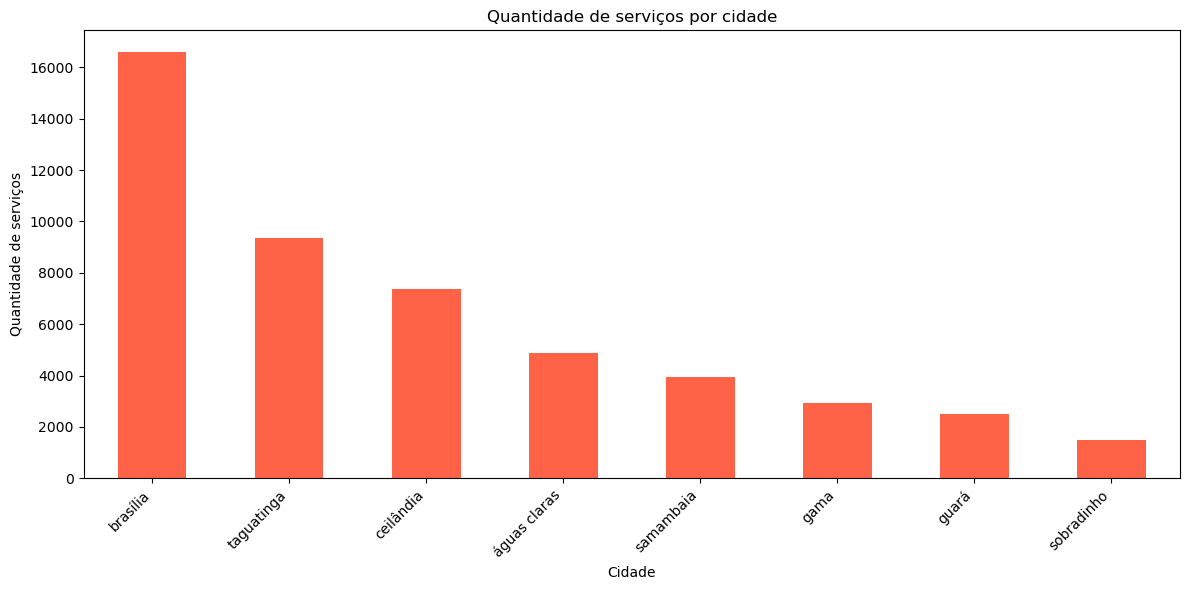

In [25]:
servicos_por_cidade = df["cidade"].value_counts().sort_values(ascending=False)

print("--- Serviços por cidade ---")
print(servicos_por_cidade.head(10))

plt.figure(figsize=(12, 6))
servicos_por_cidade.head(10).plot(
kind="bar",
color="tomato"
)

plt.title("Quantidade de serviços por cidade")
plt.xlabel("Cidade")
plt.ylabel("Quantidade de serviços")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

--- Formas de pagamento ---
forma_pagamento
PIX                  18651
Cartão de Crédito    14281
Cartão de Débito      8309
Dinheiro              4889
Boleto                2925
Name: count, dtype: int64


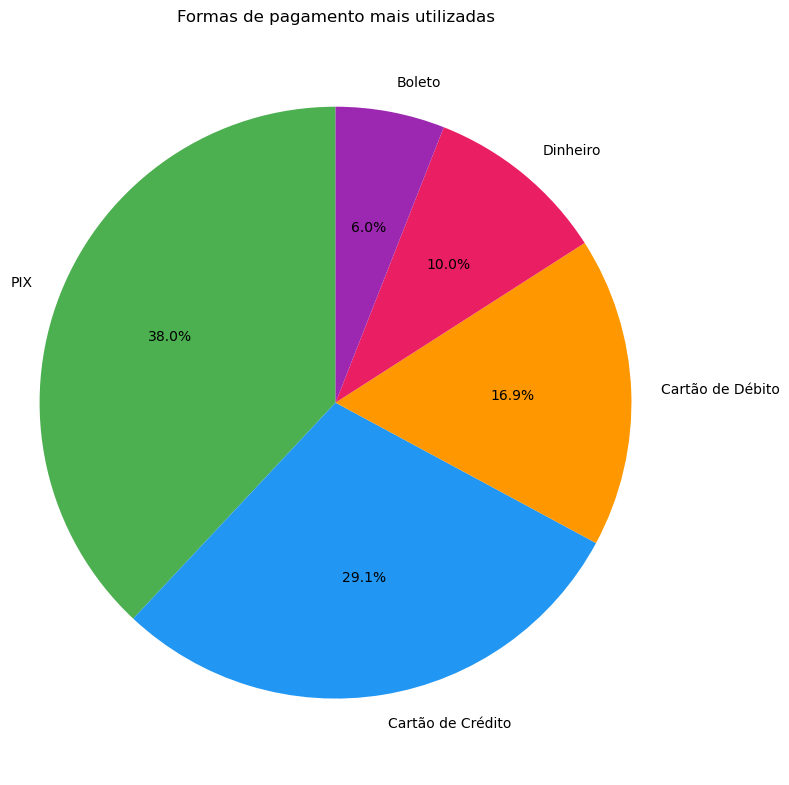

In [26]:
formas_pagamento = df["forma_pagamento"].value_counts().sort_values(ascending=False)

print("--- Formas de pagamento ---")
print(formas_pagamento)

plt.figure(figsize=(8, 8))
plt.pie(
formas_pagamento.values,
labels=formas_pagamento.index,
autopct="%1.1f%%",
startangle=90,
colors=["#4CAF50", "#2196F3", "#FF9800", "#E91E63", "#9C27B0"]
)

plt.title("Formas de pagamento mais utilizadas")
plt.axis("equal")
plt.tight_layout()
plt.show()

PARTE 7 – DESAFIO
Utilizando as demais informações disponíveis no dataset, crie DOIS NOVOS GRÁFICOS
diferentes dos quatro solicitados anteriormente.
Você deverá definir o que deseja analisar.
Para cada gráfico, apresente:
Pergunta:
O que você deseja descobrir com os dados?
Gráfico:
Qual tipo de gráfico foi utilizado?
Conclusão:
O que o resultado apresentado pelo gráfico permite concluir?

--- Valor médio por mês ---
data_servico
2025-01-01    826.622793
2025-02-01     805.77148
2025-03-01     795.21864
2025-04-01    837.071987
2025-05-01    793.360713
2025-06-01    802.551302
2025-07-01    831.220706
2025-08-01    811.355089
2025-09-01     848.07444
2025-10-01     830.52436
2025-11-01    811.398422
2025-12-01    807.772661
Name: valor_servico, dtype: Float64


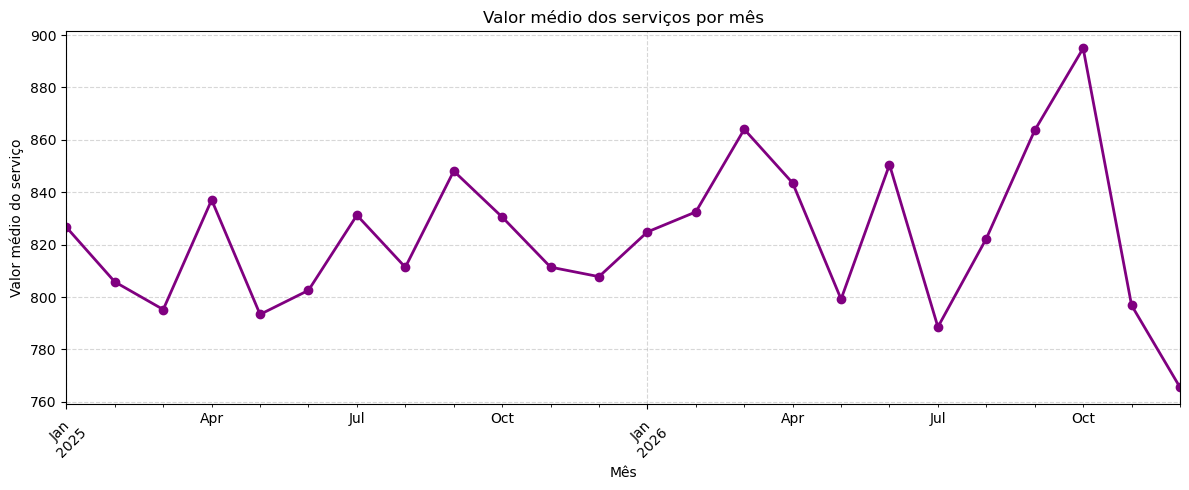

In [27]:
df["data_servico"] = pd.to_datetime(df["data_servico"], errors="coerce")

valor_medio_por_mes = (
df.groupby(df["data_servico"].dt.to_period("M").dt.to_timestamp())["valor_servico"]
.mean()
.sort_index()
)

print("--- Valor médio por mês ---")
print(valor_medio_por_mes.head(12))

plt.figure(figsize=(12, 5))
valor_medio_por_mes.plot(
kind="line",
marker="o",
color="purple",
linewidth=2
)

plt.title("Valor médio dos serviços por mês")
plt.xlabel("Mês")
plt.ylabel("Valor médio do serviço")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

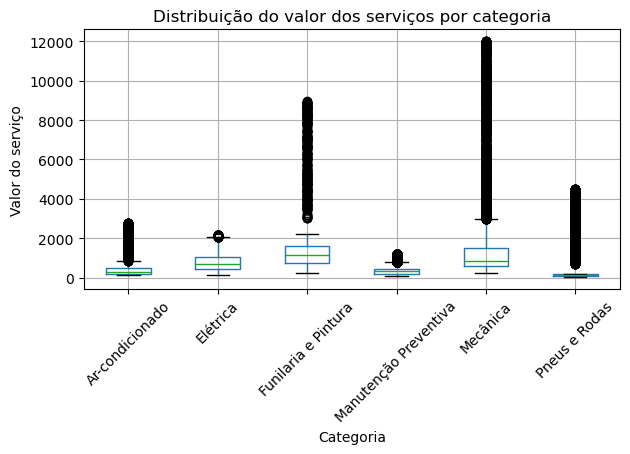

In [28]:
plt.figure(figsize=(12, 6))
df.boxplot(
column="valor_servico",
by="categoria",
grid=True,
rot=45,
fontsize=10
)

plt.title("Distribuição do valor dos serviços por categoria")
plt.suptitle("") # remove o título extra do pandas
plt.xlabel("Categoria")
plt.ylabel("Valor do serviço")
plt.tight_layout()
plt.show()